✅ Setup complete!

CREATING SAMPLE DATA
✅ Created data!
  - Training samples: 800
  - Testing samples: 200
  - Features: ['temperature', 'humidity', 'hour', 'day_of_week', 'month', 'load_type_residential', 'load_type_commercial', 'load_type_industrial', 'weekend', 'holiday']

TRAINING MODEL
✅ Model trained!
  - RMSE: 7.3106
  - R²: 0.8339
  - Saved as: best_model.joblib

APPLYING PCA
✅ PCA applied!
  - Original features: 10
  - PCA components: 10

CREATING VISUALIZATIONS


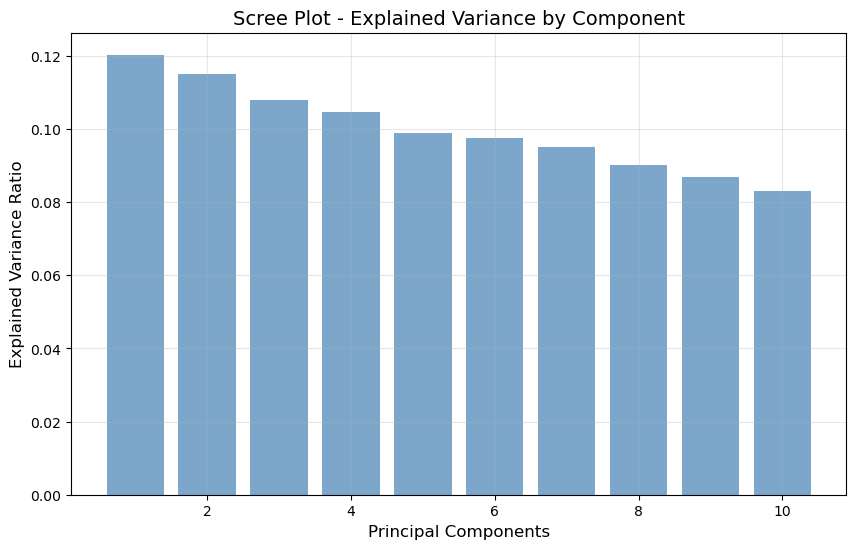

✅ Saved: static/scree_plot.png


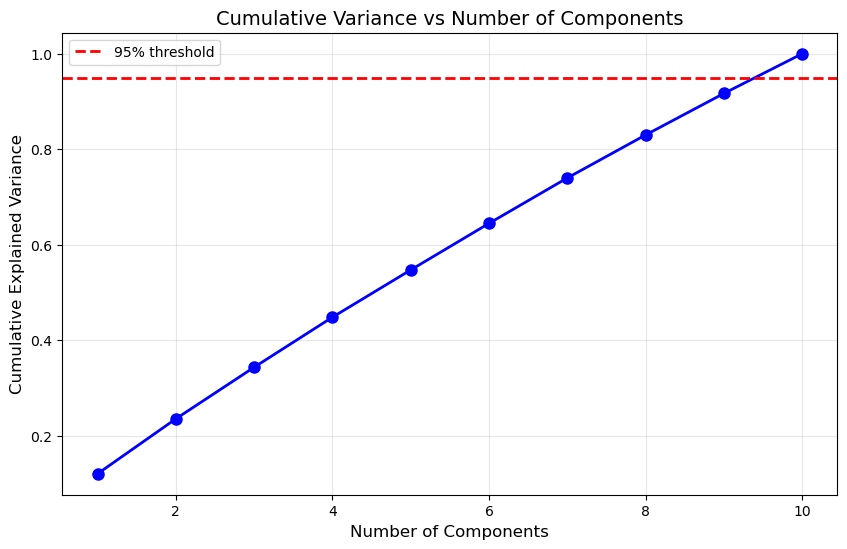

✅ Components needed for 95% variance: 10
✅ Saved: static/cumulative_variance.png

MODEL COMPARISON


C:\Users\Talha Khan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



--------------------------------------------------
Model                RMSE            R²             
--------------------------------------------------
Original             18.7589      -0.0939
3 PCA                18.5198      -0.0662
95% PCA              11.0991      0.6171
--------------------------------------------------


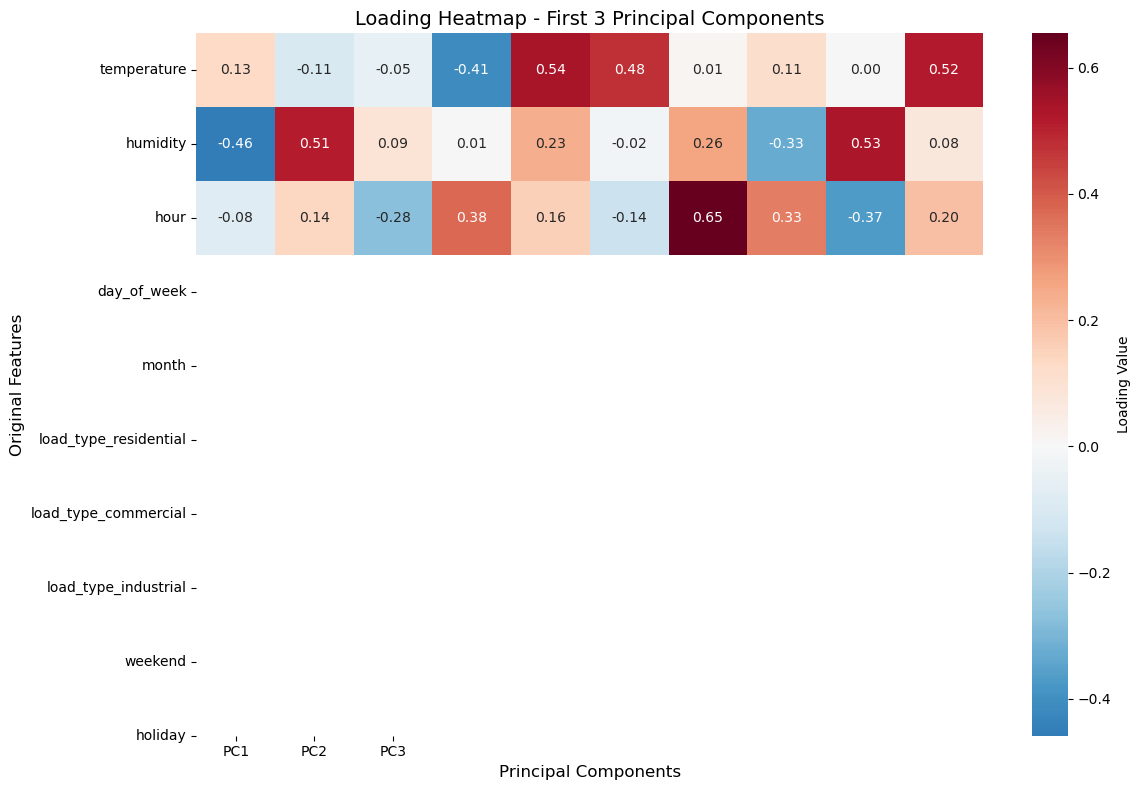

✅ Saved: static/loading_heatmap.png

SAVING PIPELINE
✅ Pipeline saved as 'pipeline.joblib'

✅ PART 1 COMPLETE!

Files created in your folder:
  📊 Data files:
     - X_train.csv
     - X_test.csv
     - y_train.csv
     - y_test.csv
  🤖 Model files:
     - best_model.joblib
     - pipeline.joblib
  📈 Visualizations (in static/ folder):
     - scree_plot.png
     - cumulative_variance.png
     - loading_heatmap.png

🎯 NEXT STEP: Run FastAPI Server
   In terminal: uvicorn main:app --reload


In [6]:
# ============================================
# WEEK 3 TASK - COMPLETE SOLUTION
# ============================================

# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Create folders
os.makedirs('static', exist_ok=True)
print("✅ Setup complete!")

# ============================================
# Cell 2: Create Sample Data
# ============================================
print("\n" + "="*60)
print("CREATING SAMPLE DATA")
print("="*60)

np.random.seed(42)
n = 1000

# Create features that might affect energy consumption
X = pd.DataFrame({
    'temperature': np.random.normal(25, 5, n),
    'humidity': np.random.normal(60, 10, n),
    'hour': np.random.randint(0, 24, n),
    'day_of_week': np.random.randint(0, 7, n),
    'month': np.random.randint(1, 13, n),
    'load_type_residential': np.random.randint(0, 2, n),
    'load_type_commercial': np.random.randint(0, 2, n),
    'load_type_industrial': np.random.randint(0, 2, n),
    'weekend': np.random.randint(0, 2, n),
    'holiday': np.random.randint(0, 2, n),
})

# Create target (energy consumption)
y = pd.DataFrame({
    'energy_consumption': (
        50 + 
        2 * X['temperature'] + 
        0.5 * X['humidity'] + 
        3 * (X['hour'] - 12)**2 / 10 +
        2 * X['day_of_week'] +
        5 * X['load_type_industrial'] +
        3 * X['load_type_commercial'] +
        np.random.normal(0, 5, n)
    )
})

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Save the data
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(f"✅ Created data!")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Testing samples: {len(X_test)}")
print(f"  - Features: {list(X.columns)}")

# ============================================
# Cell 3: Train a Model
# ============================================
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

y_train_flat = y_train.values.ravel()
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train_flat)

# Save the model
joblib.dump(model, 'best_model.joblib')

# Test the model
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ Model trained!")
print(f"  - RMSE: {rmse:.4f}")
print(f"  - R²: {r2:.4f}")
print(f"  - Saved as: best_model.joblib")

# ============================================
# Cell 4: Scale and Apply PCA
# ============================================
print("\n" + "="*60)
print("APPLYING PCA")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"✅ PCA applied!")
print(f"  - Original features: {X_train.shape[1]}")
print(f"  - PCA components: {pca.n_components_}")

# ============================================
# Cell 5: Scree Plot
# ============================================
print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, 
        color='steelblue', alpha=0.7)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot - Explained Variance by Component', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('static/scree_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved: static/scree_plot.png")

# ============================================
# Cell 6: Cumulative Variance
# ============================================
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), 
         cumulative_variance, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% threshold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Variance vs Number of Components', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('static/cumulative_variance.png', dpi=100, bbox_inches='tight')
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Saved: static/cumulative_variance.png")

# ============================================
# Cell 7: Model Comparison
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Load the trained model
best_model = joblib.load('best_model.joblib')
y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# 1. Original model
y_pred_original = best_model.predict(X_test_scaled)
rmse_original = np.sqrt(mean_squared_error(y_test_flat, y_pred_original))
r2_original = r2_score(y_test_flat, y_pred_original)

# 2. 3 PCA components
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)

model_3 = RandomForestRegressor(n_estimators=100, random_state=42)
model_3.fit(X_train_pca3, y_train_flat)
y_pred_3 = model_3.predict(X_test_pca3)
rmse_3 = np.sqrt(mean_squared_error(y_test_flat, y_pred_3))
r2_3 = r2_score(y_test_flat, y_pred_3)

# 3. 95% PCA components
pca_95 = PCA(n_components=n_components_95)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)

model_95 = RandomForestRegressor(n_estimators=100, random_state=42)
model_95.fit(X_train_pca95, y_train_flat)
y_pred_95 = model_95.predict(X_test_pca95)
rmse_95 = np.sqrt(mean_squared_error(y_test_flat, y_pred_95))
r2_95 = r2_score(y_test_flat, y_pred_95)

# Display results
print("\n" + "-"*50)
print(f"{'Model':<20} {'RMSE':<15} {'R²':<15}")
print("-"*50)
print(f"{'Original':<20} {rmse_original:.4f}      {r2_original:.4f}")
print(f"{'3 PCA':<20} {rmse_3:.4f}      {r2_3:.4f}")
print(f"{'95% PCA':<20} {rmse_95:.4f}      {r2_95:.4f}")
print("-"*50)

# ============================================
# Cell 8: Loading Heatmap
# ============================================
loadings = pca_3.components_
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, 
            xticklabels=[f'PC{i+1}' for i in range(3)],
            yticklabels=X_train.columns,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt='.2f',
            cbar_kws={'label': 'Loading Value'})
plt.title('Loading Heatmap - First 3 Principal Components', fontsize=14)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Original Features', fontsize=12)
plt.tight_layout()
plt.savefig('static/loading_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved: static/loading_heatmap.png")

# ============================================
# Cell 9: Save Pipeline
# ============================================
print("\n" + "="*60)
print("SAVING PIPELINE")
print("="*60)

pipeline = {
    'scaler': scaler,
    'pca': pca_95,
    'model': model_95
}

joblib.dump(pipeline, 'pipeline.joblib')

print("✅ Pipeline saved as 'pipeline.joblib'")

# ============================================
# Cell 10: Summary
# ============================================
print("\n" + "="*60)
print("✅ PART 1 COMPLETE!")
print("="*60)
print("\nFiles created in your folder:")
print("  📊 Data files:")
print("     - X_train.csv")
print("     - X_test.csv")
print("     - y_train.csv")
print("     - y_test.csv")
print("  🤖 Model files:")
print("     - best_model.joblib")
print("     - pipeline.joblib")
print("  📈 Visualizations (in static/ folder):")
print("     - scree_plot.png")
print("     - cumulative_variance.png")
print("     - loading_heatmap.png")
print("\n" + "="*60)
print("🎯 NEXT STEP: Run FastAPI Server")
print("   In terminal: uvicorn main:app --reload")
print("="*60)

In [7]:
import os
print("Files in week3_task folder:")
for file in os.listdir('.'):
    if file.endswith('.csv') or file.endswith('.joblib') or file == 'static':
        print(f"  ✅ {file}")

Files in week3_task folder:
  ✅ best_model.joblib
  ✅ pipeline.joblib
  ✅ static
  ✅ X_test.csv
  ✅ X_train.csv
  ✅ y_test.csv
  ✅ y_train.csv


In [8]:
import os
print("Files in static folder:")
for file in os.listdir('static'):
    print(f"  - {file}")

Files in static folder:
  - cumulative_variance.png
  - loading_heatmap.png
  - scree_plot.png
